# Deriving the Zamolodchikov rules

The Zamolodchikov relation of type A₃ is the one relation of the diagrammatic
category that involves all three colours. In the package it enters twice: as
the axiom Z1, and as a second rule Z2 that is computed from Z1 with the
structural rules. This notebook shows both.

In [1]:
using DiagrammaticHecke
debug_circular(true)

true

## 1. The cycle of reduced words

The longest element of A₃ has 16 reduced words; the 14 essentially different
ones close into a cycle under braid moves. `Zamo(i, j)` is the morphism that
walks the cycle forward from word `i` to word `j`, one braid node per step.

In [2]:
ws = zamo_words()
for (i, w) in enumerate(ws)
    println(lpad(i, 2), ": ", join(w))
end

 1: 121321
 2: 212321
 3: 213231
 4: 213213
 5: 231213
 6: 232123
 7: 323123
 8: 321323
 9: 321232
10: 312132
11: 132132
12: 132312
13: 123212
14: 123121


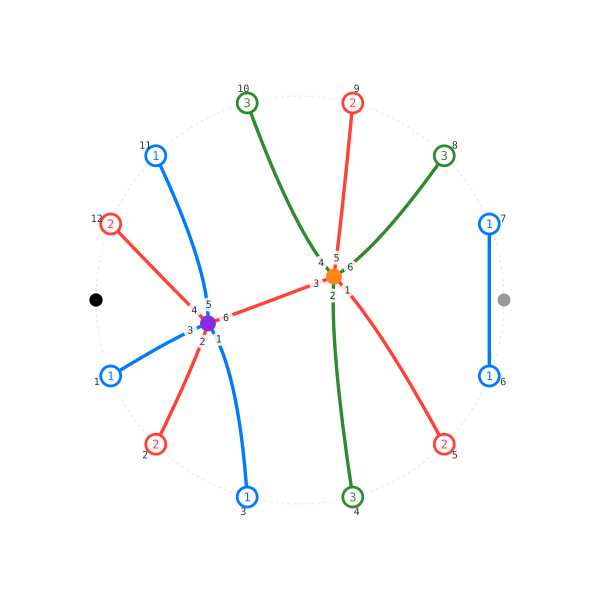

bottom(Zamo(1, 3)) = [1, 2, 1, 3, 2, 1]
top(Zamo(1, 3)) = [2, 1, 3, 2, 3, 1]


In [3]:
display(Zamo(1, 3))          # two braid moves
@show bottom(Zamo(1, 3)) top(Zamo(1, 3));

## 2. The axiom Z1

The two halves of the cycle, `Zamo(1, 8)` and `rev(Zamo(8, 1))`, are two
morphisms `121321 → 321323` with seven braid nodes each. The relation states
that they are equal; as a rule it replaces the second by the first.

bottom(A) == bottom(B) = true
top(A) == top(B) = true


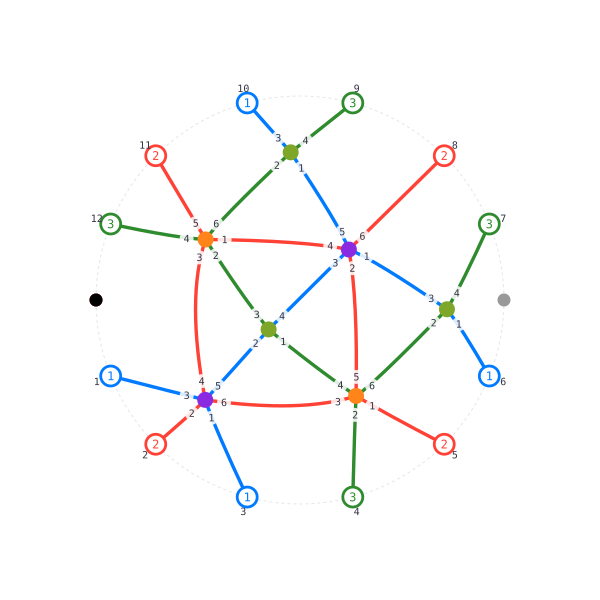

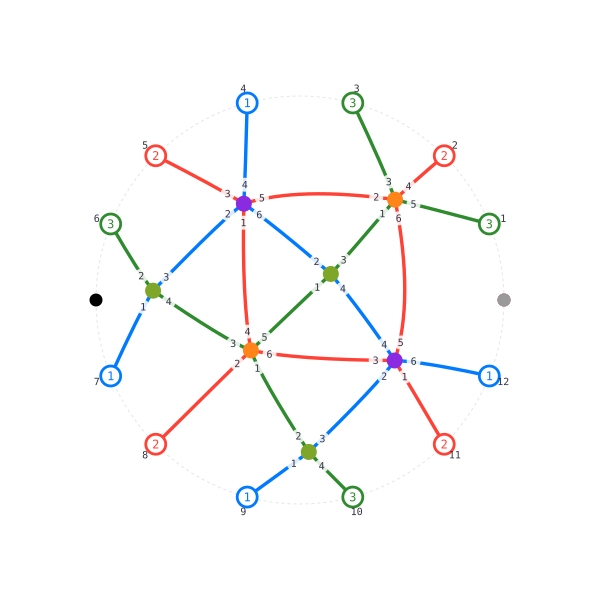

In [4]:
A = Zamo(1, 8)
B = flip(Zamo(8, 1))
@show bottom(A) == bottom(B) top(A) == top(B)
display(A); display(B)

In [5]:
z1 = zamo_term_rules(z2 = false)
@show z1[1].name length(z1[1].rhs);

(z1[1]).name = :zamo_1_8
length((z1[1]).rhs) = 1


## 3. Deriving Z2

Multiply both sides of Z1 by `rev(Zamo(1, 2))` below and `Zamo(8, 9)` above:

    X = rev(Zamo(1,2)) ∘ Zamo(1,8)      ∘ Zamo(8,9)
    Y = rev(Zamo(1,2)) ∘ rev(Zamo(8,1)) ∘ Zamo(8,9)

`X = Y` by Z1. Both are morphisms `213213 → 323123` with nine braid nodes; the
structural rules reduce each to two terms.

bottom(X) = [2, 1, 2, 3, 2, 1]
top(X) = [3, 2, 1, 2, 3, 2]
bottom(Y) = [2, 1, 2, 3, 2, 1]
top(Y) = [3, 2, 1, 2, 3, 2]


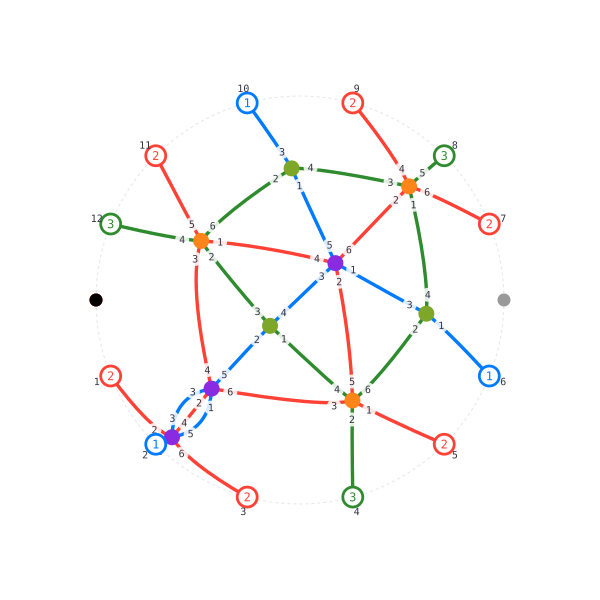

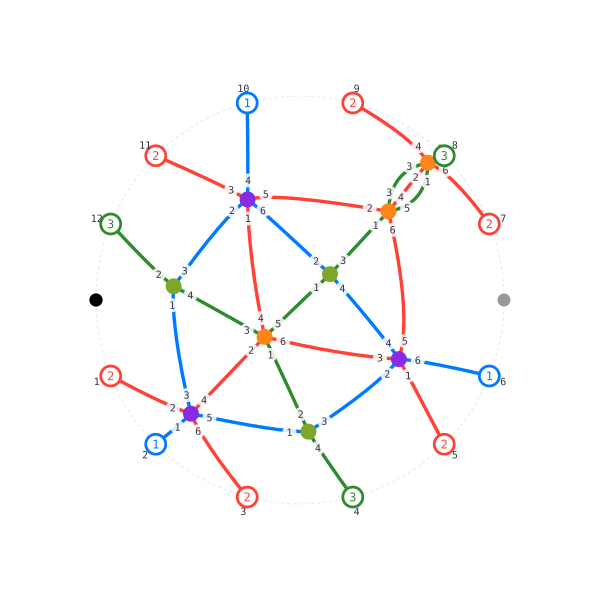

In [6]:
X = compose(flip(Zamo(1, 2)), compose(A, Zamo(8, 9)))
Y = compose(flip(Zamo(1, 2)), compose(B, Zamo(8, 9)))
@show bottom(X) top(X) bottom(Y) top(Y);
display(X); display(Y)

hX = [:braid_back, :dot_walks_on, :merge, :dot_into_braid, :dot_walks_on, :dot_into_braid, :merge, :two_adjacent_merge, :dot_walks_on, :two_adjacent_merge, :braid_back, :gen12_merge, :needle, :braid_on_gen12, :braid_relation, :merge, :mono_double, :trivalent_into_gen12, :mono_double, :trivalent_into_gen12, :trivalent_into_gen12]


Coefficient 1   degree 0
   Labels: 

—   outer: 1   nodes: [(:mixed, 

[1]), (:mixed, [1]), (:mixed, [1]), (:mixed, [3]), (:mixed, [3]), (:braid, [3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2]), (:mixed, [3])]


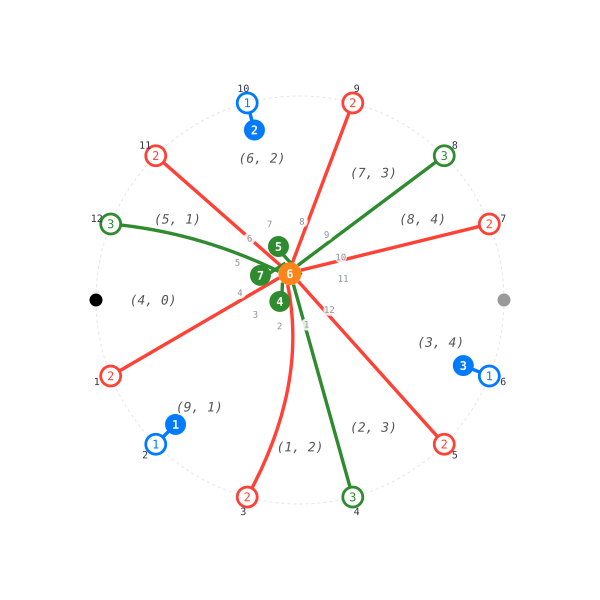

Coefficient 1   degree 0
   Labels: —   outer: 1   nodes: [(:braid, [2, 3, 2, 3, 2, 3]), (:mixed, [1, 3, 1, 3]), (:mixed, [3, 1, 3, 1]), (:braid, [1, 2, 1, 2, 1, 2]), (:braid, [2, 3, 2, 3, 2, 3]), (:mixed, [1, 3, 1, 3]), (:braid, [3, 2, 3, 2, 3, 2])]


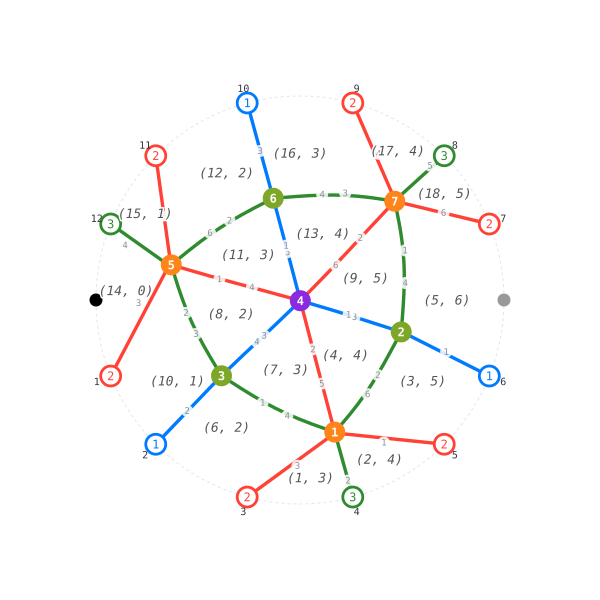

In [7]:
cX, hX = reduce_circular(circular(X.graph))
@show hX
show_combo(cX; m = circular_morphism(X))

hY = [:braid_back, :dot_walks_on, :merge, :dot_into_braid, :dot_walks_on, :dot_into_braid, :commutation_merge, :merge, :dot_walks_on, :gen12_merge, :commutation_merge, :braid_back, :needle, :merge, :braid_on_gen12, :braid_relation, :trivalent_into_gen12, :mono_double, :mono_double, :trivalent_into_gen12, :trivalent_into_gen12]
Coefficient 1   degree 0
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mixed, [3]), (:mixed, [1]), (:mixed, [1]), (:braid, [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]), (:mixed, [1])]


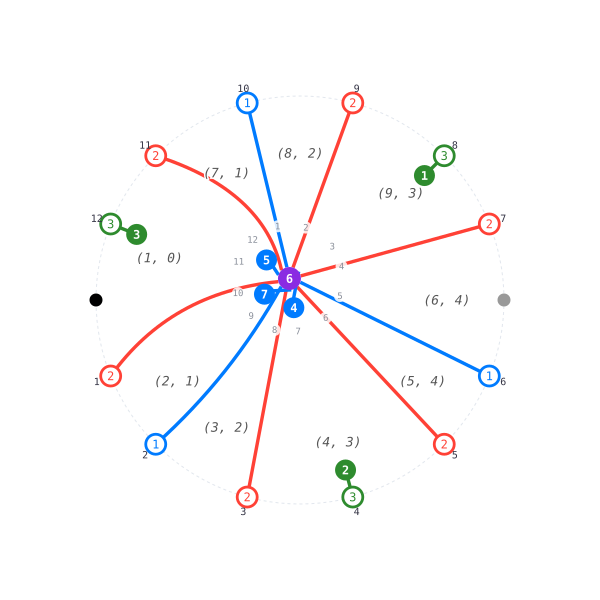

Coefficient 1   degree 0
   Labels: —   outer: 1   nodes: [(:braid, [1, 2, 1, 2, 1, 2]), (:braid, [2, 1, 2, 1, 2, 1]), (:mixed, [1, 3, 1, 3]), (:mixed, [3, 1, 3, 1]), (:braid, [3, 2, 3, 2, 3, 2]), (:braid, [2, 1, 2, 1, 2, 1]), (:mixed, [1, 3, 1, 3])]


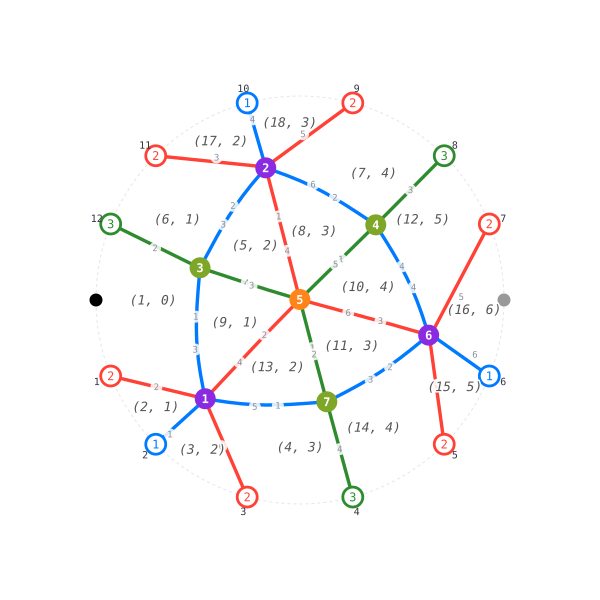

In [8]:
cY, hY = reduce_circular(circular(Y.graph))
@show hY
show_combo(cY; m = circular_morphism(Y))

One term of `X` is `Zamo(2, 9)` and one term of `Y` is `rev(Zamo(9, 2))`; the
other two, `X15` and `Y15`, carry a merged node each. Hence

    rev(Zamo(9,2)) = Zamo(2,9) + X15 − Y15,

which is the rule Z2. `zamo_term_rules()` performs exactly this computation
and stores the three right-hand sides.

In [9]:
rules = zamo_term_rules()
for R in rules
    println(R.name, ": ", length(R.rhs), " term(s) with coefficients ", [c for (_, c) in R.rhs])
end

zamo_1_8: 1 term(s) with coefficients [1]
zamo_2_9: 3 term(s) with coefficients [1, 1, -1]


## 4. Applying the rules

`zamo_pass` replaces every term of a sum whose morphism key matches a
left-hand side. Starting from `rev(Zamo(9, 2))` itself, one pass gives the
three-term right-hand side.

fired = [:zamo_2_9]
Coefficient -1   degree 0
   Labels: —   outer: 1   nodes: [(:mixed, [3]), (:mixed, [3]), (:mixed, [3]), (:mixed, [1]), (:mixed, [1]), (:braid, [1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]), (:mixed, [1])]


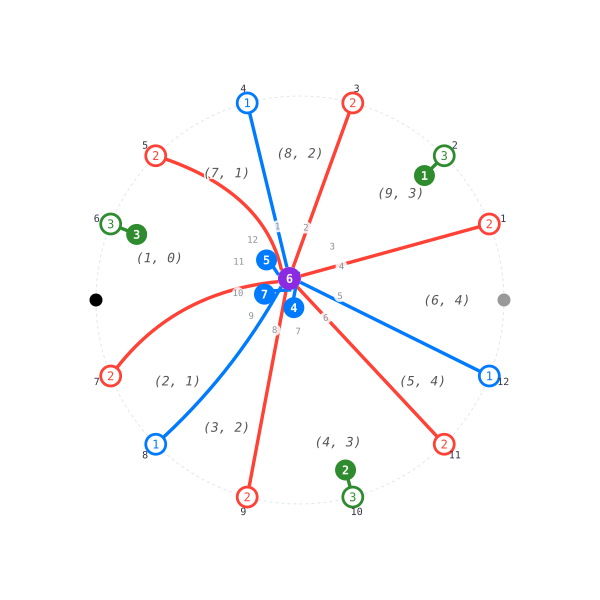

Coefficient 1   degree 0
   Labels: —   outer: 1   nodes: [(:braid, [2, 3, 2, 3, 2, 3]), (:mixed, [1, 3, 1, 3]), (:mixed, [3, 1, 3, 1]), (:braid, [1, 2, 1, 2, 1, 2]), (:braid, [2, 3, 2, 3, 2, 3]), (:mixed, [1, 3, 1, 3]), (:braid, [3, 2, 3, 2, 3, 2])]


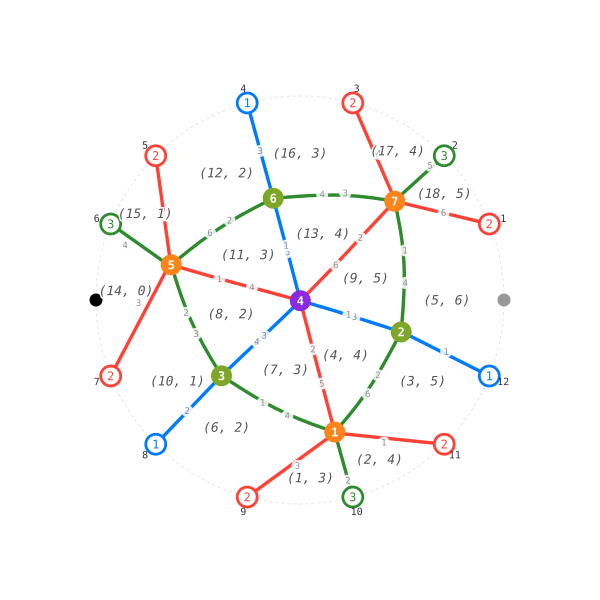

Coefficient 1   degree 0
   Labels: —   outer: 1   nodes: [(:mixed, [1]), (:mixed, [1]), (:mixed, [1]), (:mixed, [3]), (:mixed, [3]), (:braid, [3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2]), (:mixed, [3])]


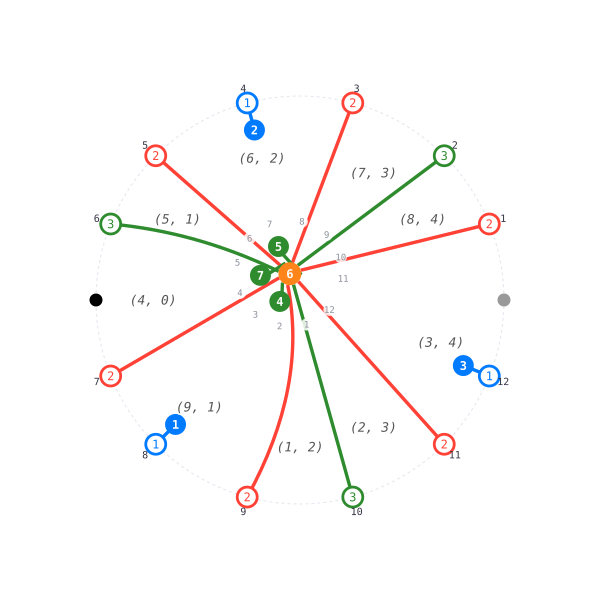

In [10]:
lhs = flip(Zamo(9, 2))
c0 = CircularComboR(circular_decorated(circular(lhs.graph)))
c1, fired = zamo_pass(c0, lhs.cut1)
@show fired
show_combo(c1; m = circular_morphism(lhs))

Inside `reduce_to_circular_leave` the same replacement runs as the `:zamo`
step; `circular_trace` shows it firing on the left-hand side of Z1.

Step 1: :zamo 7 nodes 4 Braids → 7 nodes 4 Braids
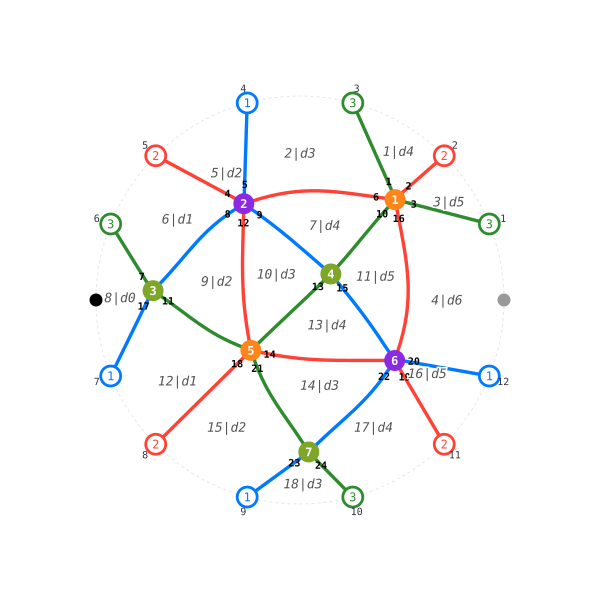
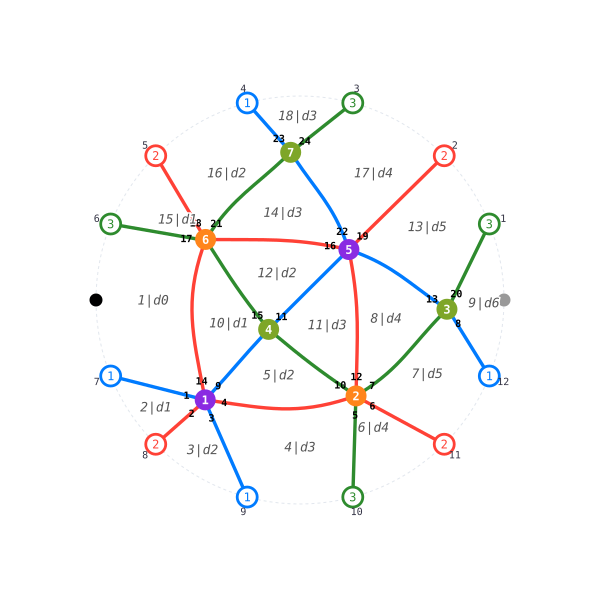

FIXED POINT after 1 steps:  1 terms, node counts [7]


Step sequence: [:zamo]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(121321323123, 7 nodes, 24 edges))

In [11]:
fz = circular_morphism(B)
circular_trace(fz.graph, fz; steps = circular_steps(:zamo))

## 5. The relation as a consequence

Everything above takes Z1 as an axiom. The rest of the notebook switches the
Zamolodchikov rules off (`cl_reduce(m; zamo = false)`) and asks whether the
remaining rules already force the relation.

With the rules off, `Zamo(1, 8)` and `rev(Zamo(8, 1))` reduce to two different
circular leaves `CL₁` and `CL₂`. At the word pair `(121321, 321323)` there are
exactly two double leaves of degree ≤ 0: the full leaf `DL(111111|111111)`,
whose circular leaf is `CL₁` again, and `DL(100100|101000)`, whose circular
leaf `CL₃` is a third one. The most general degree-0 relation between the two
sides therefore reads

    CL₁ − λ₁·CL₂ = λ₂·CL₃

with two unknown scalars `λ₁, λ₂`.

In [12]:
key(c) = Set(circular_canonical_key(d) for (d, _) in pairs_of(c))
for zamo in (true, false)
    same = key(cl_reduce(A; zamo = zamo)) == key(cl_reduce(B; zamo = zamo))
    println("Zamolodchikov rules ", zamo ? "on:  " : "off: ", "same circular leaf?  ", same)
end

Zamolodchikov rules on:  same circular leaf?  true
Zamolodchikov rules off: same circular leaf?  false


In [13]:
x1, y1 = ws[1], ws[8]
small = [d for d in double_leaves(x1, y1) if d.degree <= 0]
println("double leaves of degree <= 0 at ", join(x1), " -> ", join(y1), ": ",
        join(("DL($(join(d.e))|$(join(d.f)))" for d in small), ", "))
leaves = Any[]                       # (name, circular leaf), distinct by canonical key
function record!(name, m)
    c = cl_reduce(m; zamo = false)
    length(pairs_of(c)) == 1 || error(name, " reduces to ", length(pairs_of(c)), " terms")
    leaf, coeff = first(pairs_of(c))
    isone(coeff) || error(name, " has coefficient ", coeff)
    k = circular_canonical_key(leaf)
    j = findfirst(l -> circular_canonical_key(l[2]) == k, leaves)
    j === nothing && (push!(leaves, (name, leaf)); j = length(leaves))
    println(rpad(name, 22), "->  CL", j, "  (", length(leaf.graph.nodes), " nodes)")
end
record!("Zamo(1,8)", A)
record!("rev(Zamo(8,1))", B)
for d in small
    record!("DL($(join(d.e))|$(join(d.f)))", d.morphism)
end
println(length(leaves), " circular leaves of degree <= 0 with the rules off")

double leaves of degree <= 0 at 121321 -> 321323: DL(111111|111111), DL(100100|101000)
Zamo(1,8)             

->  CL1  (9 nodes)


rev(Zamo(8,1))        ->  CL2  (9 nodes)
DL(111111|111111)     ->  CL1  (9 nodes)


DL(100100|101000)     ->  CL3  (5 nodes)
3 circular leaves of degree <= 0 with the rules off


Zamo(1,8)


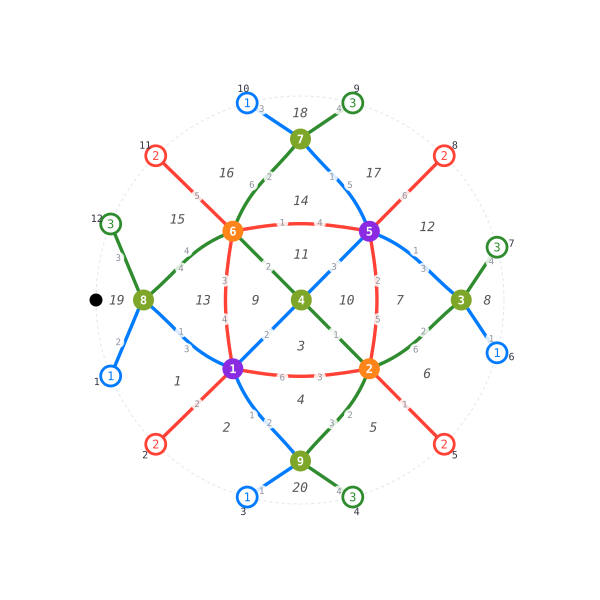

rev(Zamo(8,1))


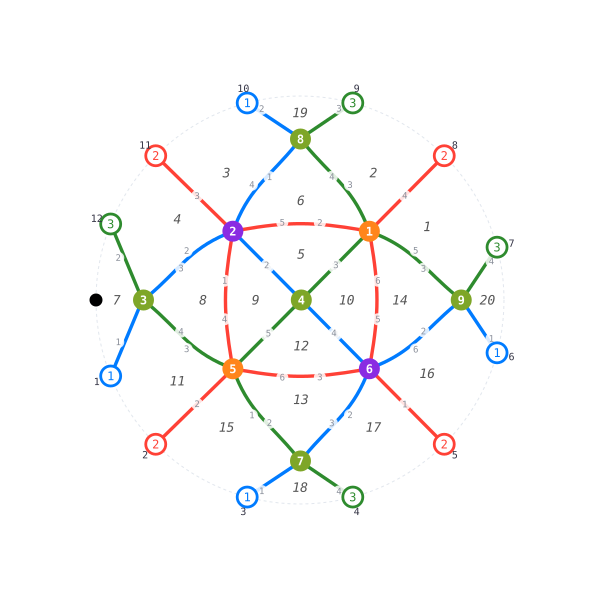

DL(100100|101000)


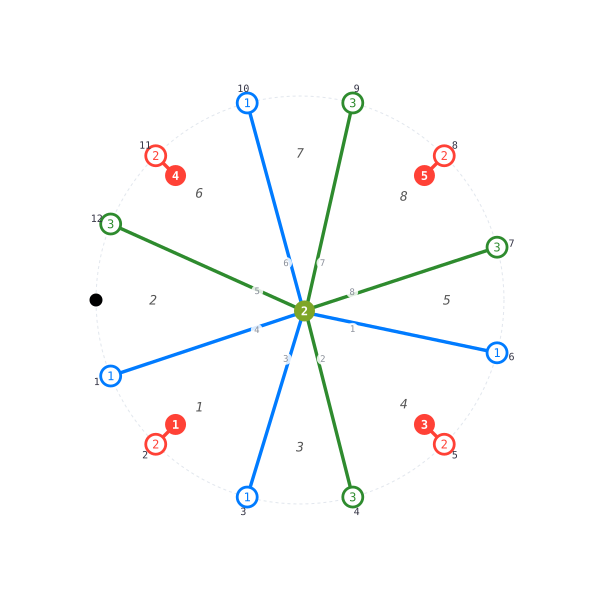

In [14]:
for (name, leaf) in leaves
    println(name)
    display(leaf)
end

## 6. Transport around the cycle

A **stage** glues one braid move below and one above:

    stage(t, f) = rev(Zamo(t, t+1)) ∘ f ∘ Zamo(t+7, t+8)

It turns a morphism for the word pair at position `t` of the cycle into one
for the pair at `t+1`. After fourteen stages the chain is back at the start
pair. Every pair carries the same kind of basis: `CL₁` from `Zamo(a, b)`,
`CL₂` from `rev(Zamo(b, a))`, and the leaves of the remaining double leaves of
degree ≤ 0. The stage matrix `Mₜ` expresses the transported basis of pair `t`
in the basis of pair `t+1`; its entries lie in `R = ℚ[α₁,α₂,α₃]` and are all
`0` or `1` here.

In [15]:
const STAGES, HALF = 14, 7
pair(t)     = (ws[mod1(1 + t, 14)], ws[mod1(1 + t + HALF, 14)])
index(t)    = (mod1(1 + t, 14), mod1(1 + t + HALF, 14))
stage(t, f) = compose(compose(flip(Zamo(1 + t, 2 + t)), f), Zamo(1 + t + HALF, 2 + t + HALF))

"One leaf with coefficient 1, or an error."
function one_leaf(name, c)
    length(pairs_of(c)) == 1 || error(name, " reduces to ", length(pairs_of(c)), " terms")
    leaf, coeff = first(pairs_of(c))
    isone(coeff) || error(name, " has coefficient ", coeff)
    (circular_canonical_key(leaf), leaf)
end

"The circular-leaf basis of pair `t`: names, keys and the carrier morphisms."
function leaf_basis(t)
    x, y = pair(t); a, b = index(t)
    names = String[]; keys = Any[]; carriers = Any[]
    function take!(name, m)
        k, _ = one_leaf(name, cl_reduce(m; zamo = false))
        k in keys && return findfirst(==(k), keys)
        push!(names, name); push!(keys, k); push!(carriers, m)
        length(keys)
    end
    take!("Zamo($a,$b)", Zamo(a, b))
    take!("rev(Zamo($b,$a))", flip(Zamo(b, a)))
    for d in double_leaves(x, y)
        d.degree <= 0 || continue
        take!("DL($(join(d.e))|$(join(d.f)))", d.morphism)
    end
    (; names, keys, carriers, x, y)
end

bases = Dict(t => leaf_basis(t) for t in 0:STAGES)
for t in 0:STAGES
    b = bases[t]
    println("t = ", lpad(t, 2), "   ", join(b.x), " -> ", join(b.y), "   ",
            join(("CL$i = $n" for (i, n) in enumerate(b.names)), ",  "))
end

t =  0   121321 -> 321323   CL1 = Zamo(1,8),  CL2 = rev(Zamo(8,1)),  CL3 = DL(100100|101000)
t =  1   212321 -> 321232   CL1 = Zamo(2,9),  CL2 = rev(Zamo(9,2)),  CL3 = DL(111000|011100),  CL4 = DL(100110|110010)
t =  2   213231 -> 312132   CL1 = Zamo(3,10),  CL2 = rev(Zamo(10,3)),  CL3 = DL(011000|110000)
t =  3   213213 -> 132132   CL1 = Zamo(4,11),  CL2 = rev(Zamo(11,4)),  CL3 = DL(011000|110000)
t =  4   231213 -> 132312   CL1 = Zamo(5,12),  CL2 = rev(Zamo(12,5)),  CL3 = DL(011000|110000)
t =  5   232123 -> 123212   CL1 = Zamo(6,13),  CL2 = rev(Zamo(13,6)),  CL3 = DL(100110|110010),  CL4 = DL(111000|011100)
t =  6   323123 -> 123121   CL1 = Zamo(7,14),  CL2 = rev(Zamo(14,7)),  CL3 = DL(100100|101000)
t =  7   321323 -> 121321   CL1 = Zamo(8,1),  CL2 = rev(Zamo(1,8)),  CL3 = DL(101000|100100)
t =  8   321232 -> 212321   CL1 = Zamo(9,2),  CL2 = rev(Zamo(2,9)),  CL3 = DL(011100|111000),  CL4 = DL(110010|100110)
t =  9   312132 -> 213231   CL1 = Zamo(10,3),  CL2 = rev(Zamo(3,10)),  CL3 

Those names are the basis the matrices below are written in. Drawn, for the
starting pair `t = 0`: `CL₁` and `CL₂` come from the two halves of the cycle,
the rest from the double leaves of degree ≤ 0.

CL1 = Zamo(1,8)


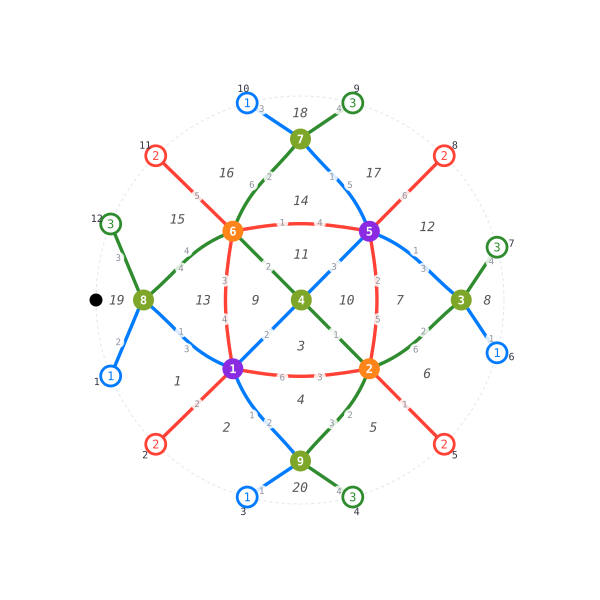

CL2 = rev(Zamo(8,1))


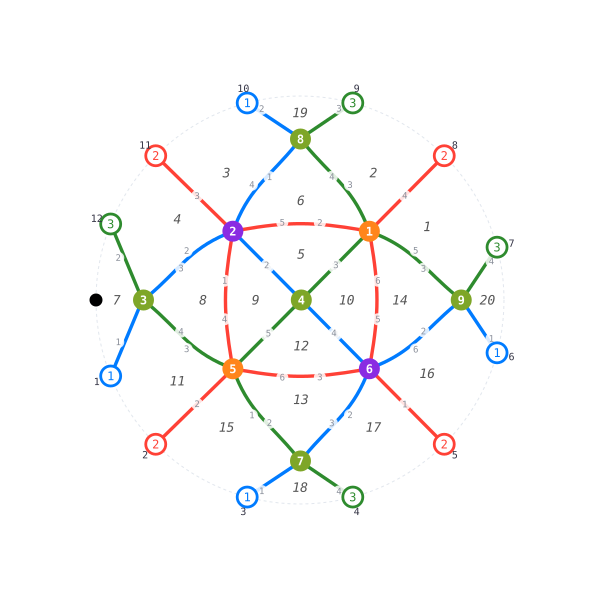

CL3 = DL(100100|101000)


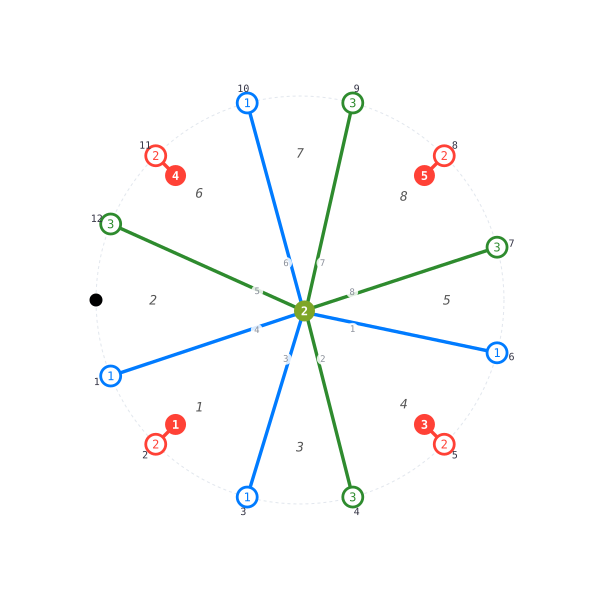

In [16]:
b0 = bases[0]
for (i, nm) in enumerate(b0.names)
    println("CL", i, " = ", nm)
    display(one_leaf(nm, cl_reduce(b0.carriers[i]; zamo = false))[2])
end

And this is what ONE stage does to a carrier: one braid move glued below, one
above. The bottom and top words each move on by one letter of the cycle, the
diagram in between grows by the two braid nodes.

carrier CL1 at t = 0:  121321 -> 321323


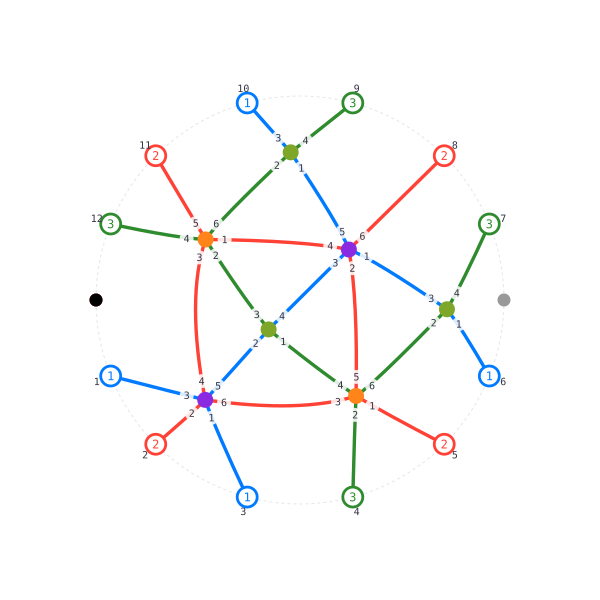

after one stage:       212321 -> 321232


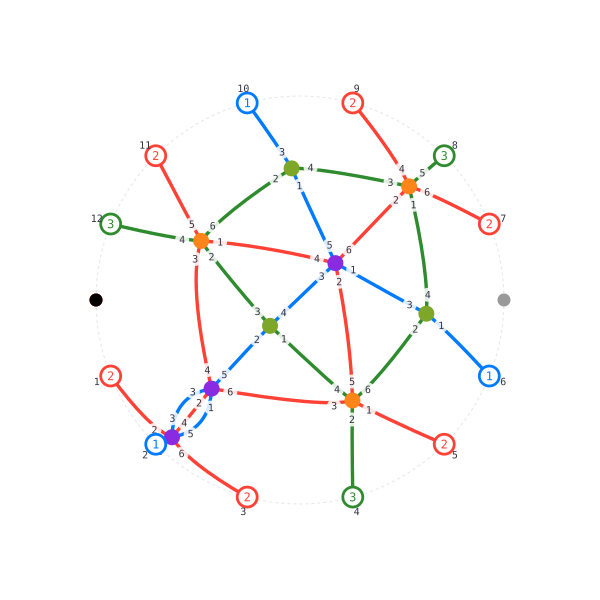

In [17]:
f0 = b0.carriers[1]
println("carrier CL1 at t = 0:  ", join(pair(0)[1]), " -> ", join(pair(0)[2]))
display(f0)
s0 = stage(0, f0)
println("after one stage:       ", join(pair(1)[1]), " -> ", join(pair(1)[2]))
display(s0)

Each stage matrix is computed by reducing the transported carriers and reading
off the leaf coefficients in the target basis. A leaf outside the target basis
would stop the computation; none occurs. This cell takes a few minutes.

In [18]:
function stage_matrices()
    Ms = Matrix{SoergelPoly}[]
    for t in 0:(STAGES - 1)
        Bt, Bn = bases[t], bases[t + 1]
        col = Dict(k => i for (i, k) in enumerate(Bn.keys))
        M = [zero(SoergelPoly) for _ in 1:length(Bn.keys), _ in 1:length(Bt.keys)]
        for (j, m) in enumerate(Bt.carriers)
            for (leaf, coeff) in pairs_of(cl_reduce(stage(t, m); zamo = false))
                k = circular_canonical_key(leaf)
                haskey(col, k) || error("stage ", t, ", column ", j, ": a leaf outside the target basis")
                M[col[k], j] += coeff
            end
        end
        push!(Ms, M)
    end
    Ms
end
Ms = stage_matrices();

In [19]:
function show_matrix(M, rows, cols)
    println("   columns: ", join(cols, ", "))
    for i in 1:size(M, 1)
        println("     [", join((rpad(string(M[i, j]), 3) for j in 1:size(M, 2)), " "), "]  ", rows[i])
    end
end
for t in 0:(STAGES - 1)
    Bt, Bn = bases[t], bases[t + 1]
    println("M_", t, "  (", size(Ms[t + 1], 1), "×", size(Ms[t + 1], 2), ")   ",
            join(Bt.x), "->", join(Bt.y), "  ⇒  ", join(Bn.x), "->", join(Bn.y))
    show_matrix(Ms[t + 1], Bn.names, Bt.names)
end

M_0  (4×3)   121321->321323  ⇒  212321->321232


   columns: Zamo(1,8), rev(Zamo(8,1)), DL(100100|101000)
     [1   0   0  ]  Zamo(2,9)
     [0   1   0  ]  rev(Zamo(9,2))
     [0   1   0  ]  DL(111000|011100)
     [1   0   0  ]  DL(100110|110010)
M_1  (3×4)   212321->321232  ⇒  213231->312132
   columns: Zamo(2,9), rev(Zamo(9,2)), DL(111000|011100), DL(100110|110010)
     [1   0   0   0  ]  Zamo(3,10)
     [0   1   0   0  ]  rev(Zamo(10,3))
     [0   0   0   0  ]  DL(011000|110000)
M_2  (3×3)   213231->312132  ⇒  213213->132132
   columns: Zamo(3,10), rev(Zamo(10,3)), DL(011000|110000)
     [1   0   0  ]  Zamo(4,11)
     [0   1   0  ]  rev(Zamo(11,4))
     [0   0   1  ]  DL(011000|110000)
M_3  (3×3)   213213->132132  ⇒  231213->132312
   columns: Zamo(4,11), rev(Zamo(11,4)), DL(011000|110000)
     [1   0   0  ]  Zamo(5,12)
     [0   1   0  ]  rev(Zamo(12,5))
     [0   0   1  ]  DL(011000|110000)
M_4  (4×3)   231213->132312  ⇒  232123->123212
   columns: Zamo(5,12), rev(Zamo(12,5)), DL(011000|110000)
     [1   0   0  ]  Zamo(6,13)
   

Three kinds of stages occur. **Branchings** (`M₀, M₄, M₇, M₁₁`, 4×3): the
target pair carries one leaf more, and the new rows copy the two Zamo columns.
**Losses** (`M₁, M₅, M₈, M₁₂`, 3×4): the leaf created one stage earlier goes to
0. The rest are identities, or carry the third leaf to its mirror image. On
`CL₁` and `CL₂` every stage is the identity.

## 7. The product, and what it decides

After seven stages the chain is at the pair `321323 → 121321`, after fourteen
back at the start. The condition on the relation is `M·v = v` for
`v = e₁ − λ₁e₂ − λ₂e₃`, a linear system in `λ₁, λ₂`. The pivots are scalars, so
the elimination stays inside `R`.

In [20]:
product(ms) = (P = ms[1]; for i in 2:length(ms); P = ms[i] * P; end; P)
eye(n) = [i == j ? one(SoergelPoly) : zero(SoergelPoly) for i in 1:n, j in 1:n]

"`p / q` inside R, allowed exactly when `q` is a nonzero scalar."
function rdiv(p::SoergelPoly, q::SoergelPoly)
    c = constant_term(q)
    (c === nothing || iszero(c)) && error("pivot ", q, " is not a nonzero scalar")
    (1 // c) * p
end

"Exact Gaussian elimination in R: solves `G * c = w`; returns `(c, solvable, rank)`."
function solve(G::Matrix{SoergelPoly}, w::Vector{SoergelPoly})
    m, n = size(G); A = hcat(copy(G), copy(w)); piv = Int[]; z = 1
    for s in 1:n
        r = findfirst(i -> !iszero(A[i, s]), z:m); r === nothing && continue
        r += z - 1; A[[z, r], :] = A[[r, z], :]
        pv = A[z, s]; for j in 1:(n + 1); A[z, j] = rdiv(A[z, j], pv); end
        for i in 1:m
            i == z && continue
            f = A[i, s]; iszero(f) && continue
            for j in 1:(n + 1); A[i, j] = A[i, j] - f * A[z, j]; end
        end
        push!(piv, s); z += 1
    end
    ok = all(iszero, A[z:m, n + 1])
    c = [zero(SoergelPoly) for _ in 1:n]
    for (r, s) in enumerate(piv); c[s] = A[r, n + 1]; end
    (c, ok, length(piv))
end

P7 = product(Ms[1:HALF])
println("product of the first seven stages   ", join(pair(0)[1]), "->", join(pair(0)[2]),
        "  ⇒  ", join(pair(HALF)[1]), "->", join(pair(HALF)[2]))
show_matrix(P7, bases[HALF].names, bases[0].names)
M = product(Ms)
println("\nproduct of all fourteen stages")
show_matrix(M, bases[0].names, bases[0].names)

product of the first seven stages   121321->321323  ⇒  321323->121321
   columns: Zamo(1,8), rev(Zamo(8,1)), DL(100100|101000)
     [1   0   0  ]  Zamo(8,1)
     [0   1   0  ]  rev(Zamo(1,8))
     [0   0   0  ]  DL(101000|100100)

product of all fourteen stages
   columns: Zamo(1,8), rev(Zamo(8,1)), DL(100100|101000)
     [1   0   0  ]  Zamo(1,8)
     [0   1   0  ]  rev(Zamo(8,1))
     [0   0   0  ]  DL(100100|101000)


In [21]:
n = length(bases[0].keys)
D = M - eye(n)
c, ok, rank = solve(hcat((D[:, j] for j in 2:n)...), D[:, 1])
println("CL1 - λ1·CL2 - λ2·CL3 = 0  with  M·v = v:   rank ", rank, " of ", n - 1,
        ok ? ",  solvable" : ",  not solvable")
println("particular solution:  ", join(("λ$(j - 1) = $(c[j - 1])" for j in 2:n), ",  "))
for j in 1:n
    println("column ", j, " of M - I is zero: ", all(iszero, D[:, j]))
end

CL1 - λ1·CL2 - λ2·CL3 = 0  with  M·v = v:   rank 1 of 2,  solvable
particular solution:  λ1 = 0,  λ2 = 0


column 1 of M - I is zero: true
column 2 of M - I is zero: true
column 3 of M - I is zero: false


The same three leaves once more, now labelled by what the fourteen stages do
to them. A zero column of `M − I` means the leaf comes back to itself after one
turn — it survives the chain; the third one does not, and that is the leaf the
difference `Zamo(1,8) − rev(Zamo(8,1))` is a multiple of.

CL1 = Zamo(1,8)   column of M - I is zero: true   → survives the turn


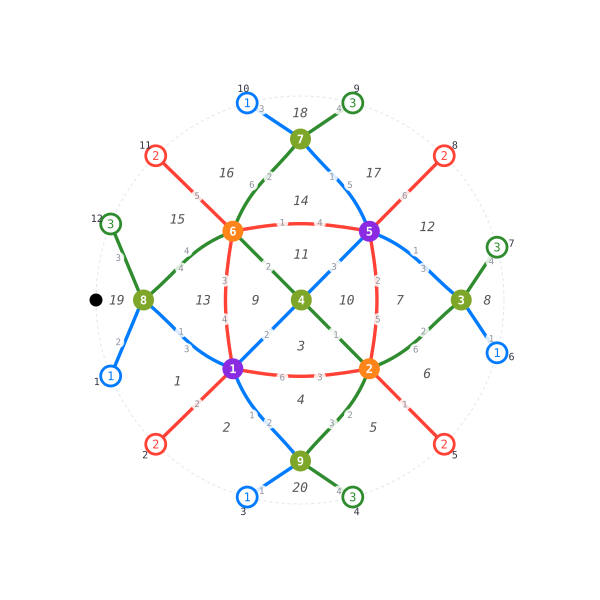

CL2 = rev(Zamo(8,1))   column of M - I is zero: true   → survives the turn


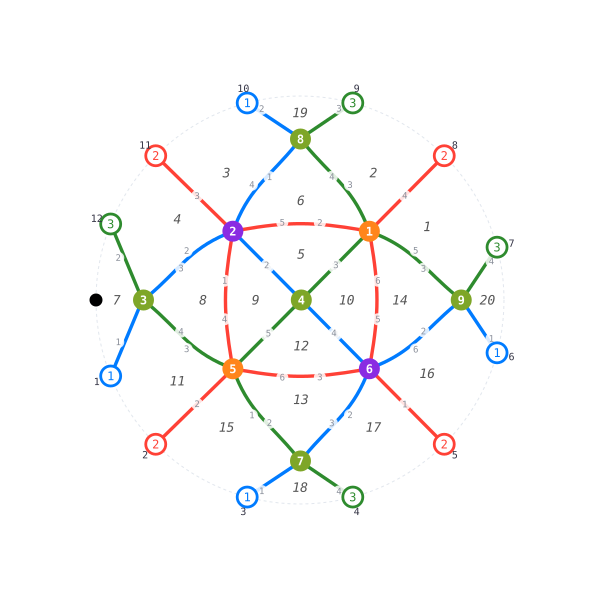

CL3 = DL(100100|101000)   column of M - I is zero: false   → dies in the chain


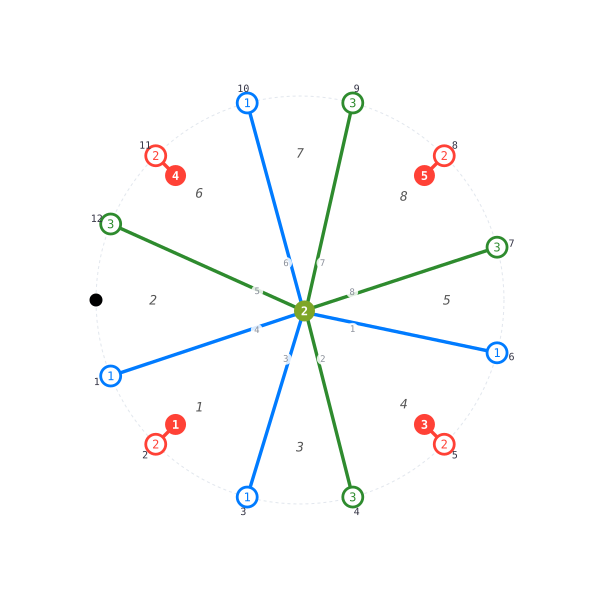

In [22]:
for i in 1:n
    surv = all(iszero, D[:, i])
    println("CL", i, " = ", b0.names[i], "   column of M - I is zero: ", surv,
            surv ? "   → survives the turn" : "   → dies in the chain")
    display(one_leaf(b0.names[i], cl_reduce(b0.carriers[i]; zamo = false))[2])
end

`M = diag(1, 1, 0)`. The columns of `M − I` at `CL₁` and `CL₂` vanish and the
column at `CL₃` is `−e₃`, so the system has rank 1 of 2 and gives

    λ₂ = 0,

while `λ₁` stays free: the chain maps `CL₁` to `CL₁` and `CL₂` to `CL₂` with
coefficient 1 and cannot relate the two sides. That is the content of the
matrix computation: there is no correction term.

`λ₁` follows from two statements about the pair `321323 → 121321`. The chain
transports the relation to `Zamo(8,1) − λ₁·rev(Zamo(1,8)) = 0`. Applying `flip`
to the relation at the start pair swaps the two places and gives
`rev(Zamo(1,8)) − λ₁·Zamo(8,1) = 0`. Together, `(1 − λ₁²)·Zamo(8,1) = 0`, so
`λ₁ = ±1`. The sign is fixed by the coefficients: with the rules off each side
reduces to a single leaf with coefficient `+1`, since braid nodes never produce
a sign, hence `λ₁ = 1`.

In [23]:
for zamo in (false, true)
    cz = cl_reduce(A; zamo = zamo)
    cr = cl_reduce(B; zamo = zamo)
    println("rules ", zamo ? "on: " : "off:", "  Zamo(1,8) -> ", length(pairs_of(cz)),
            " term, coefficient ", first(pairs_of(cz))[2],
            ";  rev(Zamo(8,1)) -> ", length(pairs_of(cr)),
            " term, coefficient ", first(pairs_of(cr))[2],
            ";  same leaf: ", key(cz) == key(cr))
end

rules off:  Zamo(1,8) -> 1 term, coefficient 1;  rev(Zamo(8,1)) -> 1 term, coefficient 1;  same leaf: false
rules on:   Zamo(1,8) -> 1 term, coefficient 1;  rev(Zamo(8,1)) -> 1 term, coefficient 1;  same leaf: true


So `Zamo(1,8) − rev(Zamo(8,1)) = 0·CL₃`: for the leaves that survive the chain,
the Zamolodchikov relation follows from the other rules.